### Describing the effect of different types of activation function of your chosen 10 CNNs

In [1]:
import tensorflow as tf
import numpy as np
import gc
from tensorflow.keras.applications import (
    VGG16, VGG19, ResNet50, ResNet101, InceptionV3,
    Xception, DenseNet121, MobileNetV2, EfficientNetB0, NASNetMobile
)
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model


IMG_SIZE = 128
BATCH_SIZE = 8
NUM_CLASSES = 20
ACTIVATIONS = ["relu", "sigmoid", "softmax"]

# Dataset (Example: CIFAR-100, pick first 20 classes)

(trainX, trainY), (testX, testY) = tf.keras.datasets.cifar100.load_data(label_mode="fine")

mask_train = np.isin(trainY, list(range(NUM_CLASSES))).flatten()
mask_test = np.isin(testY, list(range(NUM_CLASSES))).flatten()

trainX, trainY = trainX[mask_train], trainY[mask_train]
testX, testY = testX[mask_test], testY[mask_test]

trainY = tf.keras.utils.to_categorical(trainY, NUM_CLASSES)
testY = tf.keras.utils.to_categorical(testY, NUM_CLASSES)

# Convert to tf.data pipeline
def preprocess(x, y):
    x = tf.image.resize(x, (IMG_SIZE, IMG_SIZE))
    x = tf.cast(x, tf.float32) / 255.0
    return x, y

train_ds = tf.data.Dataset.from_tensor_slices((trainX, trainY))
train_ds = train_ds.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(1)

test_ds = tf.data.Dataset.from_tensor_slices((testX, testY))
test_ds = test_ds.map(preprocess).batch(BATCH_SIZE).prefetch(1)

# Build Model
def build_model(base_model_class, activation="relu"):
    base_model = base_model_class(
        include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False  # freeze backbone

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dropout(0.3)(x)
    output = Dense(NUM_CLASSES, activation=activation)(x)

    # Choose loss based on activation
    if activation == "softmax":
        loss_fn = "categorical_crossentropy"
    elif activation == "sigmoid":
        loss_fn = "binary_crossentropy" if NUM_CLASSES == 2 else "categorical_crossentropy"
    else:
        loss_fn = "categorical_crossentropy"

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer="adam", loss=loss_fn, metrics=["accuracy"])
    return model

# CNN Models

MODELS = {
    "VGG16": VGG16,
    "VGG19": VGG19,
    "ResNet50": ResNet50,
    "ResNet101": ResNet101,
    "InceptionV3": InceptionV3,
    "Xception": Xception,
    "DenseNet121": DenseNet121,
    "MobileNetV2": MobileNetV2,
    "EfficientNetB0": EfficientNetB0,
    "NASNetMobile": NASNetMobile,
}


results = {}

for model_name, model_class in MODELS.items():
    results[model_name] = {}
    for act in ACTIVATIONS:
        print(f"\n🔹 Training {model_name} with {act} activation...")

        model = build_model(model_class, activation=act)
        history = model.fit(
            train_ds,
            validation_data=test_ds,
            epochs=2,
            verbose=1
        )

        acc = history.history["val_accuracy"][-1]
        results[model_name][act] = acc

        # Free memory
        del model, history
        tf.keras.backend.clear_session()
        gc.collect()



169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step

🔹 Training VGG16 with relu activation...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/2
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.1212 - loss: 8.5995 - val_accuracy: 0.2525 - val_loss: 6.8691
Epoch 2/2
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 21ms/step - accuracy: 0.2619 - loss: nan - val_accuracy: 0.3200 - val_loss: 6.1530

🔹 Training VGG16 with sigmoid activation...
Epoch 1/2
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - accuracy: 0.2054 - loss: 2.6657 - val_accuracy: 0.5045 - val_loss: 1.9200
Epoch 2/2
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.4565 - loss: 1.9042 - val_accuracy: 0.5335 - val_loss: 1.6772

🔹 Training VGG16 with softmax activation...
Epoch 1/2
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.2006 - loss: 2.6913 - val_accuracy: 0.4700 - val_loss: 1.9295
Epoch 2/2
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.4455 - loss: 1.9090 - val_accuracy: 0.5355

In [2]:
print("\n Final Results:")
for model, acts in results.items():
    print(f"{model}: {acts}")


 Final Results:
VGG16: {'relu': 0.3199999928474426, 'sigmoid': 0.5335000157356262, 'softmax': 0.5354999899864197}
VGG19: {'relu': 0.19699999690055847, 'sigmoid': 0.4645000100135803, 'softmax': 0.4544999897480011}
ResNet50: {'relu': 0.06800000369548798, 'sigmoid': 0.08649999648332596, 'softmax': 0.09149999916553497}
ResNet101: {'relu': 0.07199999690055847, 'sigmoid': 0.1459999978542328, 'softmax': 0.11800000071525574}
InceptionV3: {'relu': 0.31299999356269836, 'sigmoid': 0.6970000267028809, 'softmax': 0.6819999814033508}
Xception: {'relu': 0.39750000834465027, 'sigmoid': 0.7634999752044678, 'softmax': 0.7615000009536743}
DenseNet121: {'relu': 0.565500020980835, 'sigmoid': 0.777999997138977, 'softmax': 0.7745000123977661}
MobileNetV2: {'relu': 0.3019999861717224, 'sigmoid': 0.7429999709129333, 'softmax': 0.7480000257492065}
EfficientNetB0: {'relu': 0.05000000074505806, 'sigmoid': 0.0494999997317791, 'softmax': 0.05000000074505806}
NASNetMobile: {'relu': 0.4819999933242798, 'sigmoid': 0.

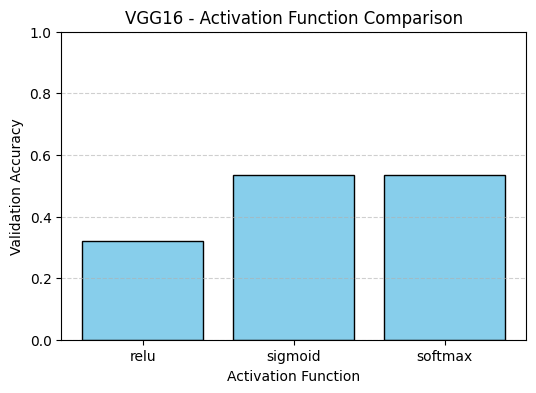

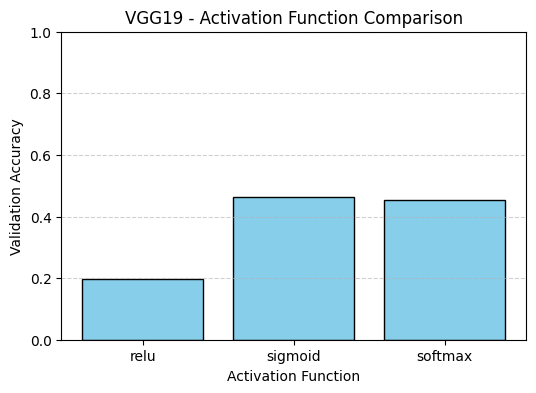

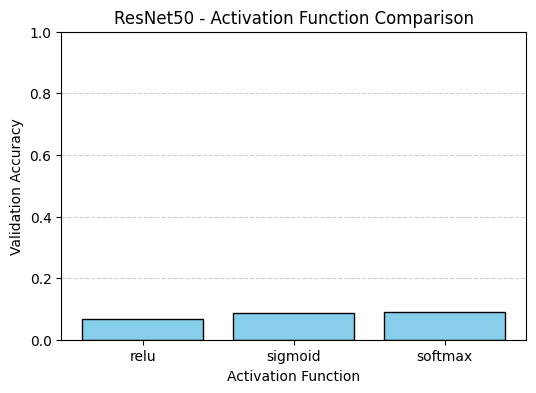

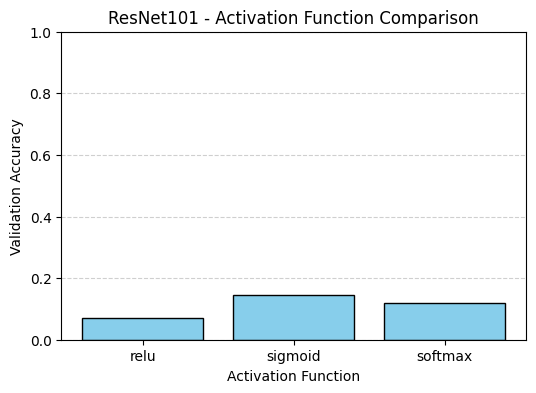

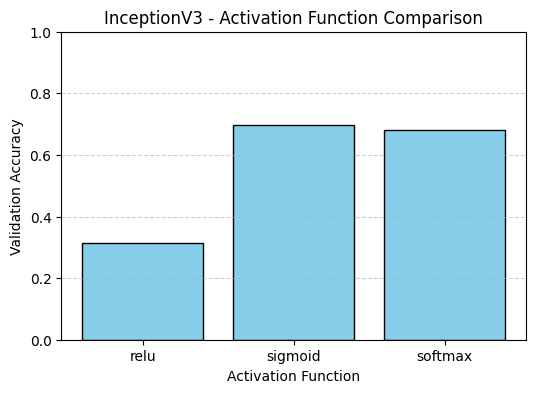

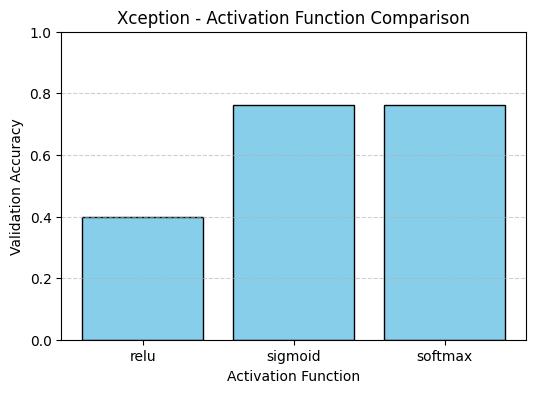

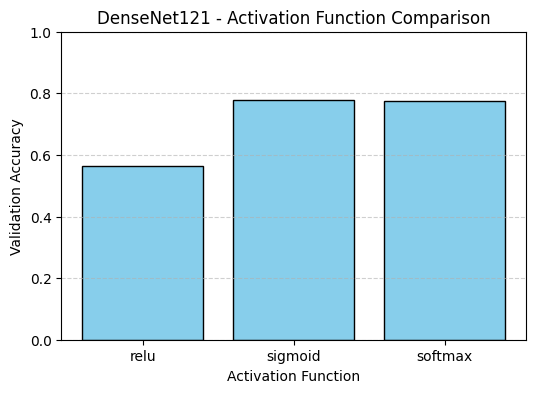

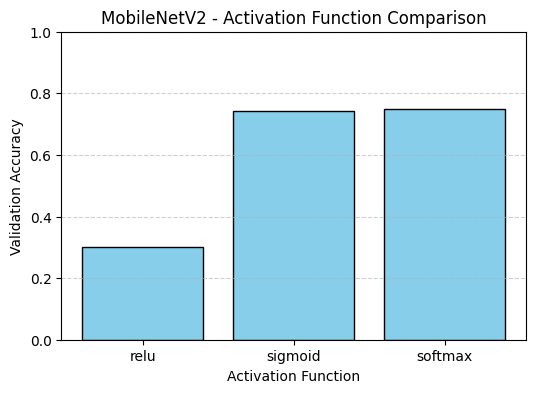

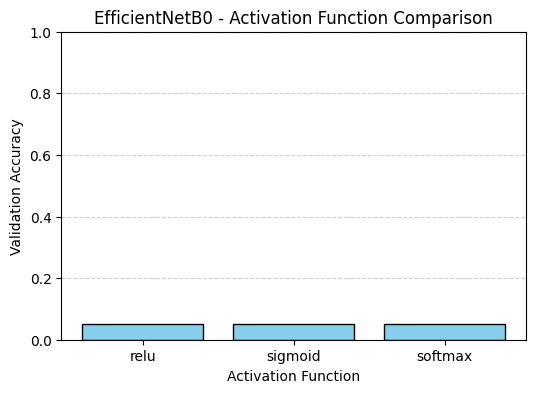

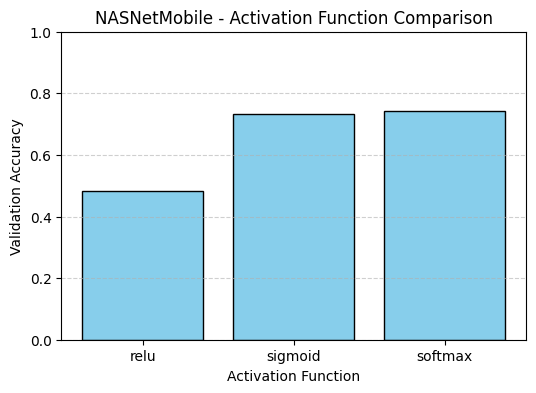

In [3]:
import matplotlib.pyplot as plt

# Plot Results

for model, acts in results.items():
    plt.figure(figsize=(6,4))
    activations = list(acts.keys())
    accuracies = list(acts.values())

    plt.bar(activations, accuracies, color="skyblue", edgecolor="black")
    plt.title(f"{model} - Activation Function Comparison")
    plt.xlabel("Activation Function")
    plt.ylabel("Validation Accuracy")
    plt.ylim(0, 1)  # since accuracy is between 0–1
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.show()


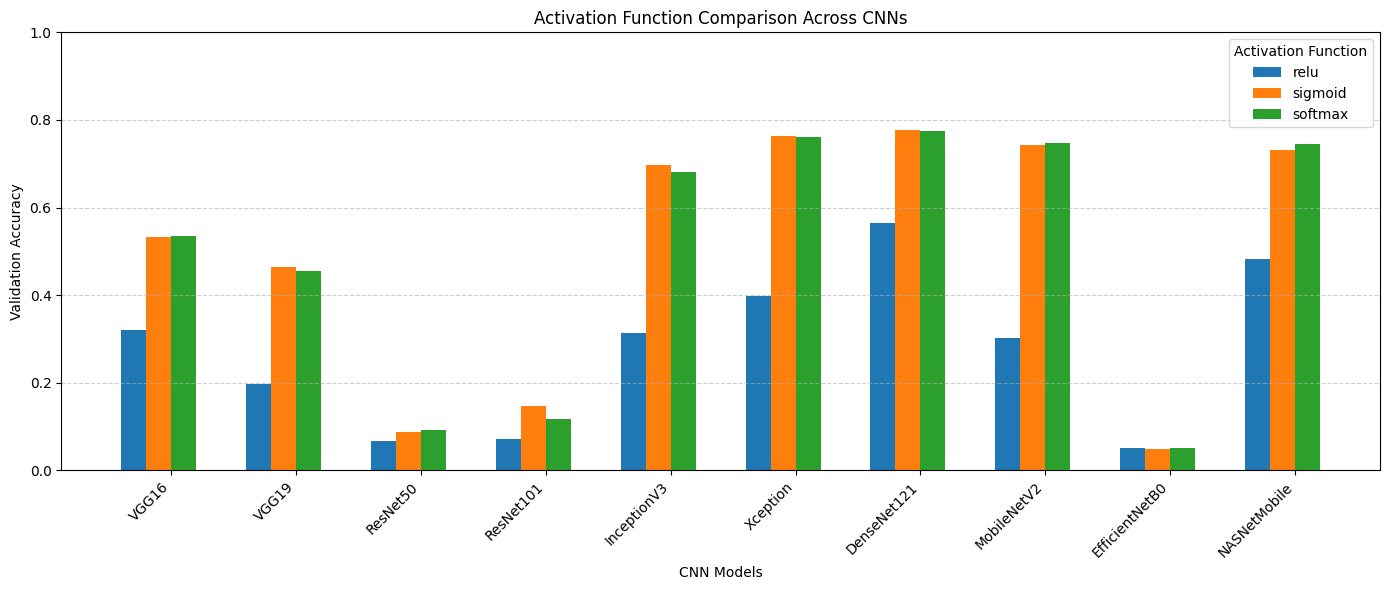

In [4]:
import matplotlib.pyplot as plt

# Plot Results
activations = ["relu", "sigmoid", "softmax"]
models = list(results.keys())

# Create grouped bar chart
x = np.arange(len(models))  # positions for CNNs
bar_width = 0.2

plt.figure(figsize=(14,6))

for i, act in enumerate(activations):
    accs = [results[m][act] for m in models]  # collect accuracy per CNN
    plt.bar(x + i*bar_width, accs, width=bar_width, label=act)

plt.xticks(x + bar_width*1.5, models, rotation=45, ha="right")
plt.xlabel("CNN Models")
plt.ylabel("Validation Accuracy")
plt.title("Activation Function Comparison Across CNNs")
plt.ylim(0, 1)
plt.legend(title="Activation Function")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()